In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [21]:
def process_data(file, year):
    df = pd.read_csv(file, parse_dates=['Date'])
    df = df[['Date', 'Daily Max 1-hour NO2 Concentration']].dropna()

    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

    df = df[df['Year'] == year]

    monthly_avg = df.groupby('Month')['Daily Max 1-hour NO2 Concentration'].mean().reset_index()
    monthly_avg['Year'] = year

    return monthly_avg.rename(columns={'Daily Max 1-hour NO2 Concentration': 'NO2 Concentration'})


In [22]:
data_2022 = process_data('dataset_2022.csv', 2022)
data_2023 = process_data('dataset_2023.csv', 2023)



In [23]:
train_df = pd.concat([data_2022, data_2023], ignore_index=True)

In [24]:
train_df['Year_2022'] = (train_df['Year'] == 2022).astype(int)
train_df['Year_2023'] = (train_df['Year'] == 2023).astype(int)
train_df['Year_2024'] = 0

In [25]:
for m in range(1, 13):
    train_df[f'Month_{m}'] = (train_df['Month'] == m).astype(int)



In [26]:
columnas = ['NO2 Concentration', 'Year_2022', 'Year_2023', 'Year_2024'] + [f'Month_{m}' for m in range(1, 13)]
train_df = train_df[columnas]

In [33]:
X_train = train_df.drop(columns=['NO2 Concentration'])
y_train = train_df['NO2 Concentration']

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [34]:
from sklearn.metrics import r2_score

# Predicción en entrenamiento
y_train_pred = model.predict(X_train)

# R2
r2 = r2_score(y_train, y_train_pred)

print("R² del modelo:", r2)

R² del modelo: 0.9286846266162915


In [35]:
test_df = pd.DataFrame({'Month': range(1, 13)})
test_df['Year_2022'] = 0
test_df['Year_2023'] = 0
test_df['Year_2024'] = 1

for m in range(1, 13):
    test_df[f'Month_{m}'] = (test_df['Month'] == m).astype(int)

columnas_x = ['Year_2022', 'Year_2023', 'Year_2024'] + [f'Month_{m}' for m in range(1, 13)]
X_test = test_df[columnas_x]

y_pred = model.predict(X_test)

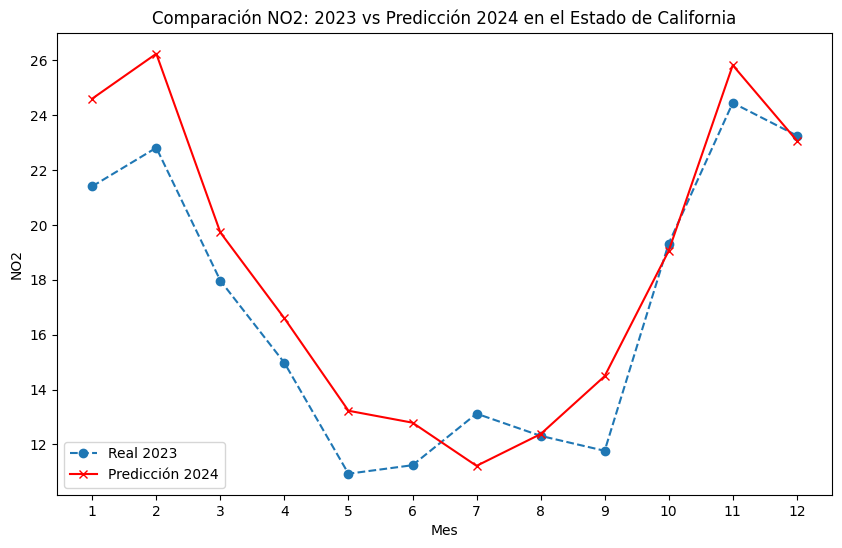

In [29]:
y_real_2023 = data_2023['NO2 Concentration'].values

plt.figure(figsize=(10, 6))
plt.plot(range(1, 13), y_real_2023, label='Real 2023', marker='o', linestyle='--')
plt.plot(range(1, 13), y_pred, label='Predicción 2024', marker='x', color='red')
plt.xticks(range(1, 13))
plt.xlabel("Mes")
plt.ylabel("NO2")
plt.title("Comparación NO2: 2023 vs Predicción 2024 en el Estado de California")
plt.legend()
plt.show()

In [17]:
def consultar_mes_2024():
    reales_2023 = data_2023.set_index('Month')['NO2 Concentration'].to_dict()

    while True:
        entrada = input("\nMes (1-12) o 'salir': ").lower()

        if entrada == 'salir':
            break

        if not entrada.isdigit() or not (1 <= int(entrada) <= 12):
            print("Ingresa un número válido.")
            continue

        mes = int(entrada)

        input_row = pd.DataFrame([{
            'Year_2022': 0,
            'Year_2023': 0,
            'Year_2024': 1,
            **{f'Month_{m}': int(m == mes) for m in range(1, 13)}
        }])

        pred = model.predict(input_row)[0]

        print(f"\nMes {mes}")
        print(f"Predicción 2024: {round(pred, 2)}")

        if mes in reales_2023:
            real = reales_2023[mes]
            print(f"Real 2023: {round(real, 2)}")

            diff = pred - real
            tendencia = "subir" if diff > 0 else "bajar"
            print(f"Tendencia: {tendencia} ({round(abs(diff), 2)})")

# Ejecutar
consultar_mes_2024()


Mes 1
Predicción 2024: 24.61
Real 2023: 21.41
Tendencia: subir (3.2)

Mes 2
Predicción 2024: 26.25
Real 2023: 22.82
Tendencia: subir (3.43)

Mes 3
Predicción 2024: 19.73
Real 2023: 17.97
Tendencia: subir (1.76)

Mes 4
Predicción 2024: 16.6
Real 2023: 14.97
Tendencia: subir (1.62)

Mes 5
Predicción 2024: 13.23
Real 2023: 10.93
Tendencia: subir (2.3)

Mes 6
Predicción 2024: 12.79
Real 2023: 11.24
Tendencia: subir (1.55)

Mes 7
Predicción 2024: 11.22
Real 2023: 13.12
Tendencia: bajar (1.9)

Mes 8
Predicción 2024: 12.37
Real 2023: 12.31
Tendencia: subir (0.06)

Mes 9
Predicción 2024: 14.49
Real 2023: 11.77
Tendencia: subir (2.72)

Mes 10
Predicción 2024: 19.06
Real 2023: 19.32
Tendencia: bajar (0.27)

Mes 11
Predicción 2024: 25.83
Real 2023: 24.45
Tendencia: subir (1.37)

Mes 12
Predicción 2024: 23.08
Real 2023: 23.26
Tendencia: bajar (0.18)
Ingresa un número válido.
Ingresa un número válido.
Ingresa un número válido.
Ingresa un número válido.


KeyboardInterrupt: Interrupted by user